# Logistic regression

## Importación de librerías y paquetes y definición de constantes

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Modelado
from sklearn.linear_model import LogisticRegression
# Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
# from tqdm import tqdm
import warnings


In [55]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

## Recopilación de datos

In [109]:
df = pd.read_csv("C:/Users/Simón/sayons-intro-ml-new/data/raw/bank-marketing-campaign-data.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Un primer paso sería declarar que significa cada variable(columna), del título de la práctica obtenemos:

| Variable           | Descripción                                                                 | Tipo de Variable |
|--------------------|------------------------------------------------------------------------------|------------------|
| age                | Edad del cliente                                                             | Numérico         |
| job                | Tipo de trabajo                                                              | Categórico       |
| marital            | Estado civil                                                                 | Categórico       |
| education          | Nivel de educación                                                           | Categórico       |
| default            | ¿Tiene crédito actualmente?                                                  | Categórico       |
| housing            | ¿Tiene un préstamo de vivienda?                                              | Categórico       |
| loan               | ¿Tiene un préstamo personal?                                                 | Categórico       |
| contact            | Tipo de comunicación de contacto                                             | Categórico       |
| month              | Último mes en el que se le ha contactado                                     | Categórico       |
| day_of_week        | Último día en el que se le ha contactado                                     | Categórico       |
| duration           | Duración del contacto previo en segundos                                     | Numérico         |
| campaign           | Número de contactos durante esta campaña al cliente                          | Numérico         |
| pdays              | Días desde la última campaña hasta el contacto actual                        | Numérico         |
| previous           | Número de contactos durante la campaña anterior                              | Numérico         |
| poutcome           | Resultado de la campaña de marketing anterior                                | Categórico       |
| emp.var.rate       | Tasa de variación del empleo (indicador trimestral)                          | Numérico         |
| cons.price.idx     | Índice de precios al consumidor (indicador mensual)                          | Numérico         |
| cons.conf.idx      | Índice de confianza del consumidor (indicador mensual)                       | Numérico         |
| euribor3m          | Tasa EURIBOR a 3 meses (indicador diario)                                    | Numérico         |
| nr.employed        | Número de empleados (indicador trimestral)                                   | Numérico         |
| y                  | TARGET: ¿Contrató un depósito a largo plazo?                                 | Categórico       |


## Análisis descriptivo 

In [110]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [111]:
df.shape

(41188, 21)

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [113]:
df.nunique()

age                 78
job                 12
marital              4
education            8
default              3
housing              3
loan                 3
contact              2
month               10
day_of_week          5
duration          1544
campaign            42
pdays               27
previous             8
poutcome             3
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
y                    2
dtype: int64

## Limpieza de datos

### Eliminar duplicados:

In [114]:
df.duplicated().sum()

np.int64(12)

### Hay 12 filas duplicadas, asi que nos aseguramos de no dejar duplicados en todo el dataset

In [115]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(41176, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [116]:
df.duplicated().sum()

np.int64(0)

### Valores nulos o faltantes:

In [117]:
df.isnull().sum().sort_values(ascending=False) / len(df)

age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64

#### No hay valores nulos, sin embargo las columnas pdays y poutcome contienen datos inservibles

### Limpieza de datos: Eliminar información irrelevante
    
Decido eliminar variables redundantes y que no aportan información destacada, en este caso: 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'month', 'day_of_week', 'duration', 'marital', 'education', 'pdays, 'poutcome'

In [118]:
df.drop(['marital', 'education', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
         'nr.employed', 'contact', 'month','day_of_week', 'pdays'], axis = 1, inplace = True)
df.head()

,age,job,default,housing,loan,duration,campaign,previous,poutcome,y
0,56,housemaid,no,no,no,261,1,0,nonexistent,no
1,57,services,unknown,no,no,149,1,0,nonexistent,no
2,37,services,no,yes,no,226,1,0,nonexistent,no
3,40,admin.,no,no,no,151,1,0,nonexistent,no
4,56,services,no,no,yes,307,1,0,nonexistent,no


In [66]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.0,32.0,38.0,47.0,98.0
campaign,41176.0,2.567879,2.770318,1.0,1.0,2.0,3.0,56.0
previous,41176.0,0.173013,0.494964,0.0,0.0,0.0,0.0,7.0


## Análisis de variables:

### Variables univariante: variables categóricas

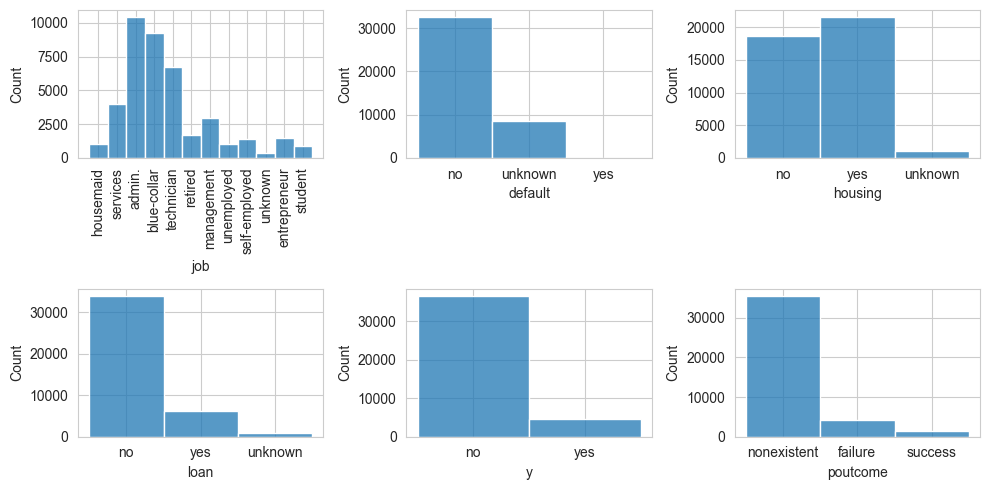

In [106]:
fig, axis = plt.subplots(2, 3, figsize=(10, 5))
sns.set_style("whitegrid")
axis[0,0].tick_params(axis='x', rotation=90)
sns.histplot(ax=axis[0,0], data=df, x="job")
sns.histplot(ax=axis[0,1], data=df, x="default")
sns.histplot(ax=axis[0,2], data=df, x="housing")
sns.histplot(ax=axis[1,0], data=df, x="loan")
sns.histplot(ax=axis[1,1], data=df, x="y")
sns.histplot(ax=axis[1,2], data=df, x="poutcome")
plt.tight_layout()
plt.show()

### Variables univariante: variables númericas

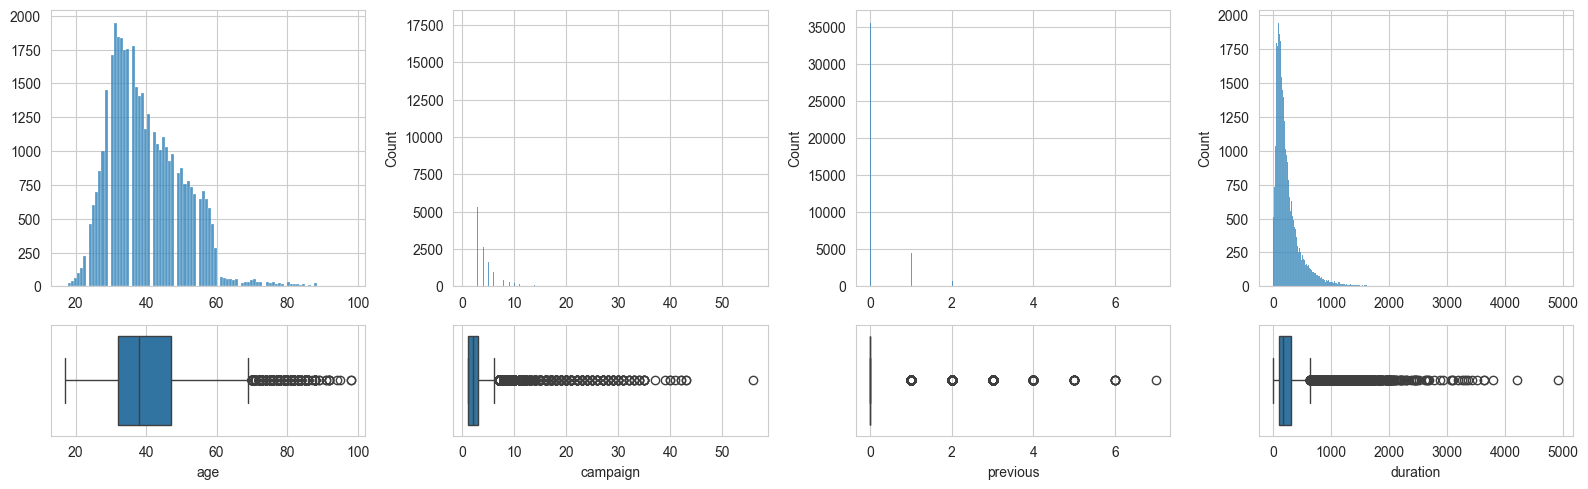

In [ ]:
fig, axis = plt.subplots(2, 4, figsize=(16, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="age").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="age")
sns.histplot(ax=axis[0, 1], data=df, x="campaign").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="campaign")
sns.histplot(ax=axis[0, 2], data=df, x="previous").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="previous")
sns.histplot(ax=axis[0, 3], data=df, x="duration").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="duration")
plt.tight_layout()
plt.show()

> #### Observaciones:
>
> - La combinación de los dos gráficos nos permite conocer las distribuciones y sus características estadísticas.
> - De la visualización resultante podemos tener claro las variables que cuentan con valores atípicos.

### Análisis de Variables Multivariante: procedemos a buscar todas las posibles relaciones que existen entre las variables

### Codificación de variables categóricas para el estudio de correlaciones, análisis númerico-categórico

In [122]:
df["job_n"] = pd.factorize(df["job"])[0]
df["default_n"] = pd.factorize(df["default"])[0]
df["housing_n"] = pd.factorize(df["housing"])[0]
df["loan_n"] = pd.factorize(df["loan"])[0]
df["y_n"] = pd.factorize(df["y"])[0]
df["poutcome_n"] = pd.factorize(df["poutcome"])[0]

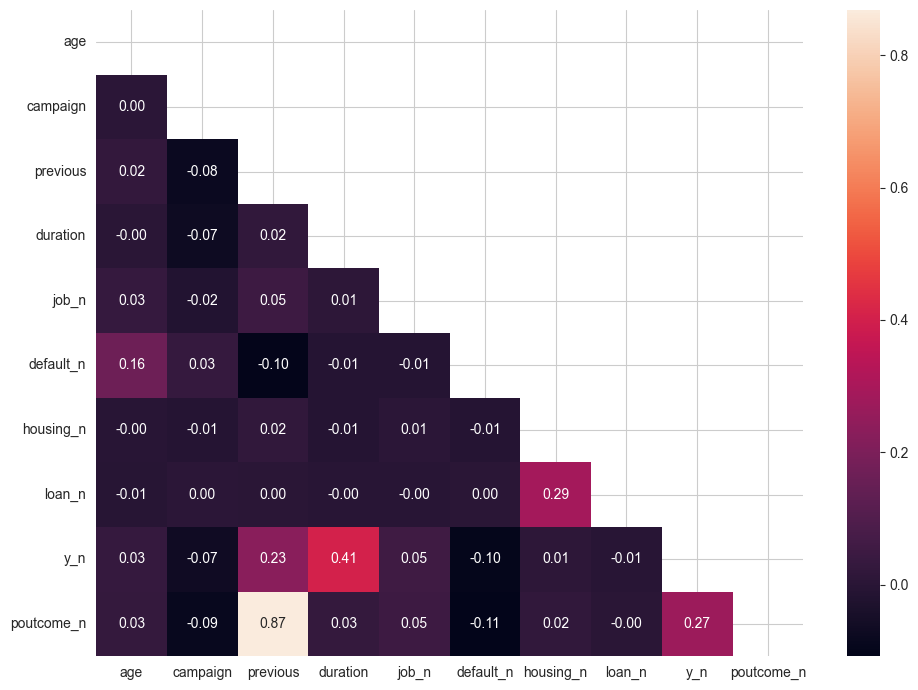

In [123]:
corr = df[['age', 'campaign', 'previous', 'duration','job_n', 'default_n', 'housing_n', 'loan_n', 'y_n', 'poutcome_n']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

### Observaciones:
Distintas correlaciones a tener en cuenta: age-default, previous-y, previous-poutcome, housing-loan, duration-y, poutcome-y

Procedemos a estudiar de forma detallada las correlaciones para sacar una conclusión

 

### Análisis de variables multivariante: númerico-númerico

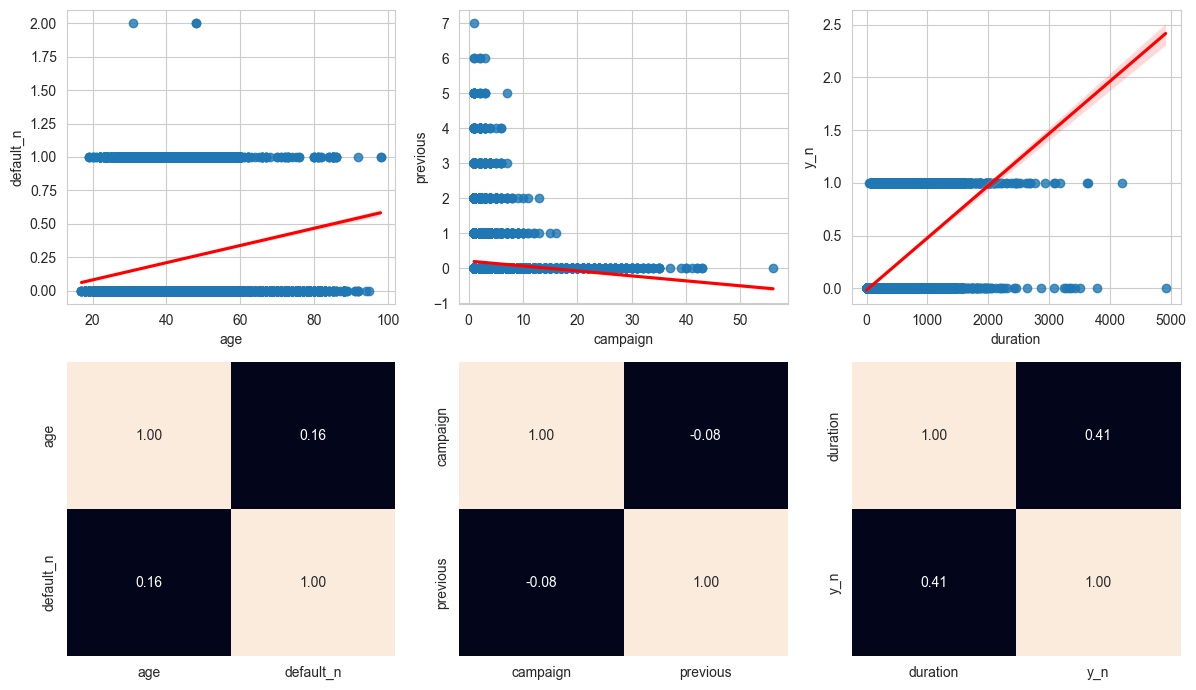

In [125]:
corr_age_default = df[["age", "default_n"]].corr()
corr_campaign_previous = df[["campaign", "previous"]].corr()
corr_duration_y = df[["duration", "y_n"]].corr()
fig, axis = plt.subplots(2, 3, figsize=(12, 7))
sns.set_style("whitegrid")
sns.regplot(ax=axis[0,0], data=df, x="age", y="default_n", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,0], data=corr_age_default, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,1], data=df, x="campaign", y="previous", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,1], data=corr_campaign_previous, annot=True, fmt=".2f", cbar=False)
sns.regplot(ax=axis[0,2], data=df, x="duration", y="y_n", line_kws={'color': 'red'})
sns.heatmap(ax=axis[1,2], data=corr_duration_y, annot=True, fmt=".2f", cbar=False)
plt.tight_layout()
plt.show()

### Observaciones:

1. No podemos concluir que la edad y tener una deuda por impago tengan relación ya que se distribuye a partes iguales por toda la distribución
2. No hay relación aparente entre el contacto con los clientes de la campaña anterior y la actual
3. Hay relación directa entre la duración de la llamada y contratar un producto

### Análisis de variables multivariante: categórico-categórico

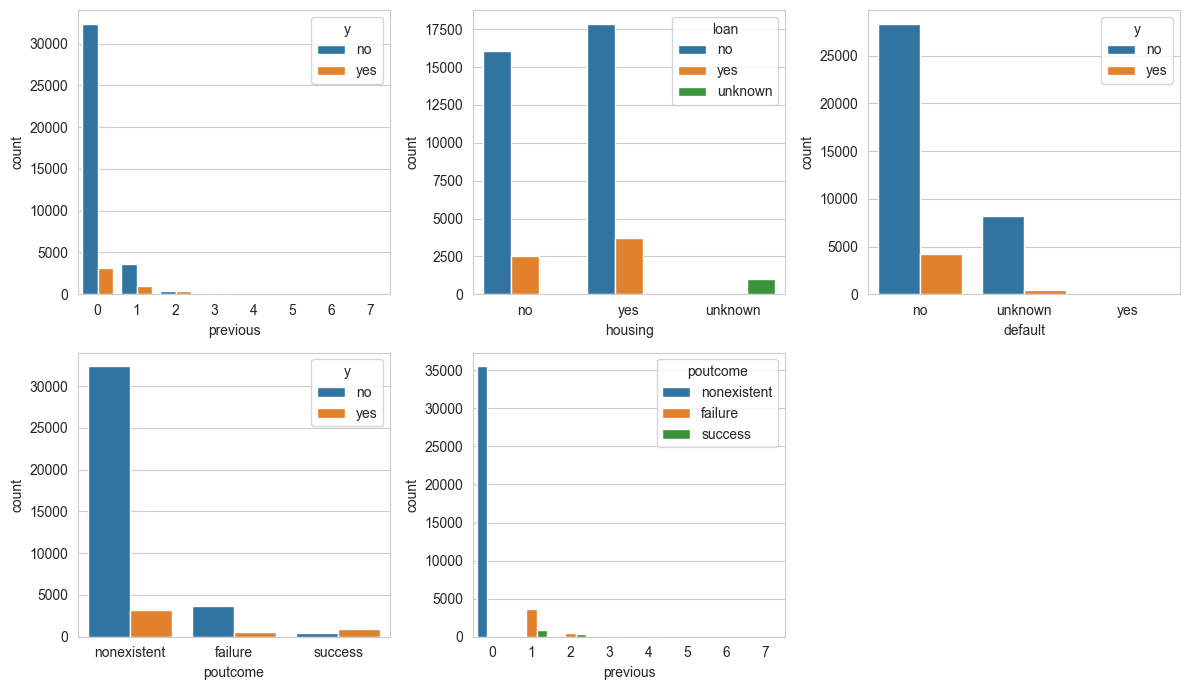

In [ ]:
fig, axis = plt.subplots(2, 3, figsize=(12, 7))
sns.set_style("whitegrid")
sns.countplot(ax=axis[0,0], data=df, x="previous", hue="y")
sns.countplot(ax=axis[0,1], data=df, x="housing", hue="loan")
sns.countplot(ax=axis[0,2], data=df, x="default", hue="y")
sns.countplot(ax=axis[1,0], data=df, x="poutcome", hue="y")
sns.countplot(ax=axis[1,1], data=df, x="previous", hue="poutcome")
fig.delaxes(axis[1, 2])
plt.tight_layout()
plt.show()

### Observaciones: 
>- Parece que el contacto con los clientes en la campaña anterior influye en la contratación del producto
>- Hay un porcentaje de clientes con préstamo hipotecario que tienen también un prestamo personal, alrededor de un 25%
>- Tener una deuda por impago no parece determinante ya que los datos se distribuyen entre no y unknown

## Ingeniería de características

### Análisis de outliers

#### Análisis descriptivo

In [131]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.0,32.0,38.0,47.0,98.0
duration,41176.0,258.315815,259.305321,0.0,102.0,180.0,319.0,4918.0
campaign,41176.0,2.567879,2.770318,1.0,1.0,2.0,3.0,56.0
previous,41176.0,0.173013,0.494964,0.0,0.0,0.0,0.0,7.0
job_n,41176.0,3.673863,2.454340,0.0,2.0,3.0,4.0,11.0
default_n,41176.0,0.208908,0.406713,0.0,0.0,0.0,0.0,2.0
housing_n,41176.0,0.571959,0.541216,0.0,0.0,1.0,1.0,2.0
loan_n,41176.0,0.199825,0.456055,0.0,0.0,0.0,0.0,2.0
y_n,41176.0,0.112663,0.316184,0.0,0.0,0.0,0.0,1.0
poutcome_n,41176.0,0.169953,0.455811,0.0,0.0,0.0,0.0,2.0


#### Visualización

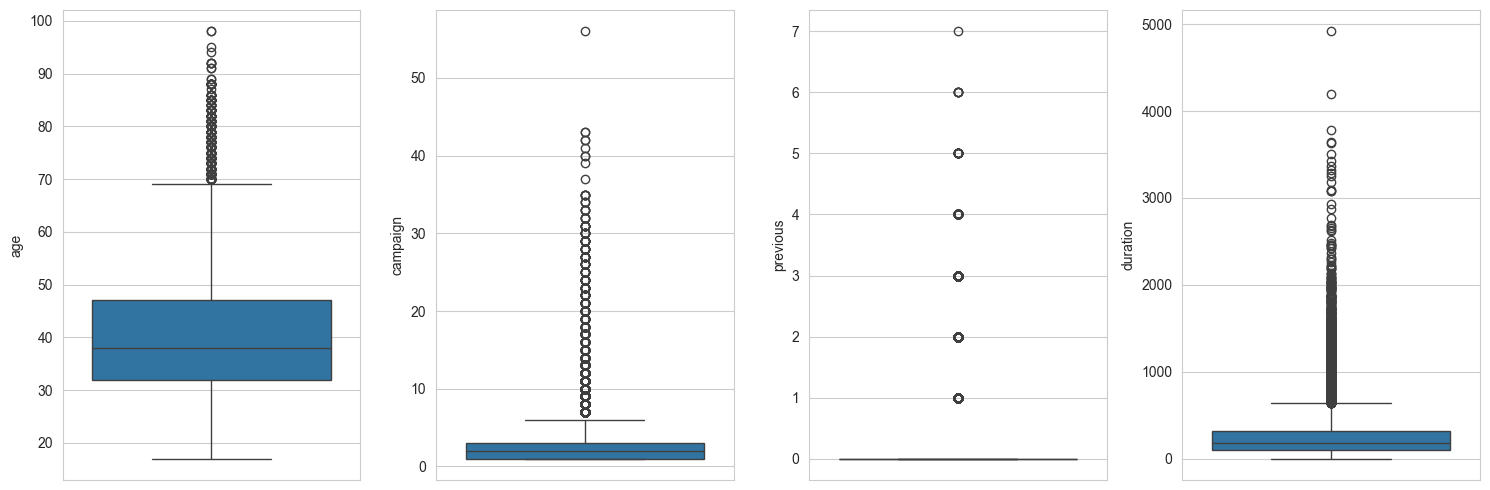

In [134]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="age")
sns.boxplot(ax=axis[1], data=df, y="campaign")
sns.boxplot(ax=axis[2], data=df, y="previous")
sns.boxplot(ax=axis[3], data=df, y="duration")
plt.tight_layout()
plt.show()

#### Valores atípicos 'age'

In [75]:
df['age'].describe()

count    41176.00000
mean        40.02380
std         10.42068
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [76]:

q1_age = df["age"].quantile(0.25)
q3_age = df["age"].quantile(0.75)
iqr_age = q3_age - q1_age

# Definir los límites inferior y superior
lower_limit_age = 0 if (q1_age - 1.5 * iqr_age) < 0 else q1_age - 1.5 * iqr_age
upper_limit_age = q3_age + 1.5 * iqr_age

f"Límite superior: {round(upper_limit_age, 2)}, Límite inferior: {round(lower_limit_age, 2)}, Rango intercuartílico: {round(iqr_age, 2)}"

'Límite superior: 69.5, Límite inferior: 9.5, Rango intercuartílico: 15.0'

In [77]:
df[df['age'] > 70]

,age,job,default,housing,loan,campaign,previous,poutcome,y,job_n,default_n,housing_n,loan_n,y_n
27757,76,retired,no,no,yes,9,0,nonexistent,no,5,0,0,1,0
27780,73,retired,no,yes,no,1,1,failure,no,5,0,1,0,0
27800,88,retired,no,yes,no,1,0,nonexistent,no,5,0,1,0,0
27802,88,retired,no,no,no,2,0,nonexistent,yes,5,0,0,0,1
27805,88,retired,no,yes,yes,5,0,nonexistent,yes,5,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40986,84,retired,unknown,yes,yes,4,1,success,no,5,1,1,1,0
40996,81,retired,no,yes,no,1,2,failure,yes,5,0,1,0,1
41004,80,retired,no,yes,no,1,1,failure,yes,5,0,1,0,1
41183,73,retired,no,yes,no,1,0,nonexistent,yes,5,0,1,0,1


#### Considero que son valores atípicos normales en la distribución y decido mantenerlos

#### Valores atípicos 'campaign'

In [78]:
df['campaign'].describe()

count    41176.000000
mean         2.567879
std          2.770318
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [79]:
q1_campaign = df['campaign'].quantile(0.25)
q3_campaign = df['campaign'].quantile(0.75)
iqr_campaign = q3_campaign - q1_campaign

# Definir los límites inferior y superior
lower_limit_campaign = 0 if (q1_campaign - 1.5 * iqr_campaign) < 0 else q1_campaign - 1.5 * iqr_campaign
upper_limit_campaign = q3_campaign + 1.5 * iqr_campaign

f"Límite superior: {round(upper_limit_campaign, 2)}, Límite inferior: {round(lower_limit_campaign, 2)}, Rango intercuartílico: {round(iqr_campaign, 2)}"

'Límite superior: 6.0, Límite inferior: 0, Rango intercuartílico: 2.0'

In [80]:
df[df['campaign']>6]

,age,job,default,housing,loan,campaign,previous,poutcome,y,job_n,default_n,housing_n,loan_n,y_n
887,54,admin.,no,no,no,7,0,nonexistent,no,2,0,0,0,0
1043,41,technician,unknown,no,no,8,0,nonexistent,no,4,1,0,0,0
1094,40,technician,no,yes,no,8,0,nonexistent,no,4,0,1,0,0
1097,51,blue-collar,unknown,yes,no,7,0,nonexistent,no,3,1,1,0,0
1230,48,blue-collar,no,no,no,7,0,nonexistent,no,3,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40611,75,retired,no,no,no,9,1,failure,no,5,0,0,0,0
40631,88,retired,no,yes,no,7,0,nonexistent,no,5,0,1,0,0
40698,29,technician,no,yes,no,7,5,success,no,4,0,1,0,0
40821,33,technician,no,yes,no,9,2,failure,no,4,0,1,0,0


#### Considero que son valores normales y mantengo los outliers.

#### Valores atípicos 'previous'

In [81]:
df['previous'].describe().T

count    41176.000000
mean         0.173013
std          0.494964
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [82]:
q1_previous = df['previous'].quantile(0.25)
q3_previous = df['previous'].quantile(0.75)
iqr_previous = q3_previous - q1_previous

# Definir los límites inferior y superior
lower_limit_previous = 0 if (q1_previous - 1.5 * iqr_previous) < 0 else q1_previous - 1.5 * iqr_previous
upper_limit_previous = q3_previous + 1.5 * iqr_previous

f"Límite superior: {round(upper_limit_previous, 2)}, Límite inferior: {round(lower_limit_previous, 2)}, Rango intercuartílico: {round(iqr_previous, 2)}"

'Límite superior: 0.0, Límite inferior: 0.0, Rango intercuartílico: 0.0'

#### Hay una incongruencia matemática y cualquier valor se puede considerar atípico, sin embargo considero mantener la variable porque me parece interesante la influencia de campañas anteriores sobre la actual

#### Valores atípicos 'duration'

In [136]:
df['duration'].describe().T

count    41176.000000
mean       258.315815
std        259.305321
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64

#### Calculo del rango inter-cuartil: IQR = Q3(75%) - Q1(25%)

In [137]:
q1_duration = df['duration'].quantile(0.25)
q3_duration = df['duration'].quantile(0.75)
iqr_duration = q3_duration - q1_duration

# Definir los límites inferior y superior
lower_limit_duration = 0 if (q1_duration - 1.5 * iqr_duration) < 0 else q1_duration - 1.5 * iqr_duration
upper_limit_duration = q3_duration + 1.5 * iqr_duration

f"Límite superior: {round(upper_limit_duration, 2)}, Límite inferior: {round(lower_limit_duration, 2)}, Rango intercuartílico: {round(iqr_duration, 2)}"

'Límite superior: 644.5, Límite inferior: 0, Rango intercuartílico: 217.0'

#### Dado que la duración puede fluctuar hacia cualquier valor, decido mantener los valores atipicos

### Análisis de valores faltantes

In [139]:
df.isnull().sum().sort_values(ascending=False) / len(df)

age           0.0
job           0.0
default       0.0
housing       0.0
loan          0.0
duration      0.0
campaign      0.0
previous      0.0
poutcome      0.0
y             0.0
job_n         0.0
default_n     0.0
housing_n     0.0
loan_n        0.0
y_n           0.0
poutcome_n    0.0
dtype: float64

#### En este caso no existen valores nulos debido a la limpieza de datos que hemos hecho previamente, así como tampoco es necesario hacer inferencia de características porque no tienen ninguna relación

## Split de datos

### Dividimos el conjunto de datos en muestras de train y test

#### Elegimos la variable 'y' como target y la codificamos en valores binarios

In [ ]:
X = df.drop(['y','y_n', 'job_n', 'default_n', 'housing_n',
             'loan_n', 'y_n', 'poutcome_n'], axis=1)
y = df['y_n']
# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

,age,job,default,housing,loan,duration,campaign,previous,poutcome
13521,49,admin.,no,no,no,105,1,0,nonexistent
18711,38,admin.,no,no,no,35,25,0,nonexistent
12887,36,admin.,no,yes,no,716,5,0,nonexistent
35835,35,technician,no,yes,no,394,1,0,nonexistent
27432,38,technician,no,yes,no,119,1,0,nonexistent
...,...,...,...,...,...,...,...,...,...
6501,33,self-employed,no,yes,yes,85,1,0,nonexistent
21640,54,technician,no,no,no,99,1,0,nonexistent
19862,52,blue-collar,no,no,no,809,1,0,nonexistent
14531,48,unemployed,no,yes,yes,200,3,0,nonexistent


## Scaling & Encoding

### Scaling

#### Usamos el método  standarscaler porque los datos están sesgados y hay valores atípicos

#### Scaling X_train

In [ ]:
standard_scaler = StandardScaler()  # Instancia de: from sklearn.preprocessing import MinMaxScaler
num_variables = ['age', 'campaign', 'previous', 'duration']
standard_train_features = standard_scaler.fit_transform(X_train[num_variables])
X_train_standard = pd.DataFrame(standard_train_features,
                               index=X_train.index,
                               columns=num_variables)
X_train_standard

,age,campaign,previous,duration
13521,0.860817,-0.568738,-0.347629,-0.586966
18711,-0.194200,8.153988,-0.347629,-0.854900
12887,-0.386021,0.885050,-0.347629,1.751713
35835,-0.481932,-0.568738,-0.347629,0.519217
27432,-0.194200,-0.568738,-0.347629,-0.533380
...,...,...,...,...
6501,-0.673753,-0.568738,-0.347629,-0.663519
21640,1.340370,-0.568738,-0.347629,-0.609932
19862,1.148549,-0.568738,-0.347629,2.107682
14531,0.764906,0.158156,-0.347629,-0.223342


#### Scaling X_test

In [ ]:
standard_test_features = standard_scaler.transform(X_test[num_variables])
X_test_standard = pd.DataFrame(standard_test_features,
                               index=X_test.index,
                               columns=num_variables)
X_test_standard

,age,campaign,previous,duration
10574,0.860817,0.158156,-0.347629,-0.900832
19836,-0.769664,-0.568738,-0.347629,-0.414723
29499,1.340370,0.885050,-0.347629,-0.307550
36472,0.668996,-0.568738,-0.347629,-0.690312
18172,-0.002379,0.885050,-0.347629,-0.740071
...,...,...,...,...
14572,-0.865575,-0.568738,-0.347629,0.702943
16616,-0.098289,1.611943,-0.347629,-0.640553
30690,-0.577843,-0.568738,-0.347629,-0.583139
24409,-0.098289,-0.568738,-0.347629,0.568976


### Encoding

#### Usamos el método one-hot encoding ya que las variables a codificar no tienen un orden determinado

#### Encoding X_train

In [ ]:
# Genero una lista con los nombres de las columnas categóricas
cat_variables = ['job', 'default', 'housing', 'loan', 'poutcome']
# Creamos la instancia del encoder
one_hot_encoder = OneHotEncoder(sparse_output=False)
# Entrenamos y aplicamos el encoder en el conjunto de entrenamiento: X_train
X_train_cat_ohe = one_hot_encoder.fit_transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe,
                               index=X_train.index,
                               columns=one_hot_encoder.get_feature_names_out(cat_variables))
X_train_cat_ohe.head()

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,poutcome_failure,poutcome_nonexistent,poutcome_success
13521,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
18711,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
12887,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
35835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
27432,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


#### Encoding X_test

In [146]:
# Entrenamos y aplicamos el encoder en el conjunto de test: X_test
X_test_cat_ohe = one_hot_encoder.transform(X_test[cat_variables])
X_test_cat_ohe = pd.DataFrame(X_test_cat_ohe,
                              index=X_test.index,
                              columns=one_hot_encoder.get_feature_names_out(cat_variables))
X_test_cat_ohe.head()

,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,poutcome_failure,poutcome_nonexistent,poutcome_success
10574,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
19836,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
29499,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
36472,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
18172,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


### Guardado de scalers y encoders

In [147]:
with open('C:/Users/Simón/sayons-intro-ml-new/data/raw/bank-marketing-campaign-data-standard-scaler.pkl', 'wb') as file:
    pickle.dump(standard_scaler, file)

In [148]:
with open('C:/Users/Simón/sayons-intro-ml-new/data/raw/bank-marketing-campaign-data-one-hot-encoder.pkl', 'wb') as file2:
    pickle.dump(one_hot_encoder, file2)

## Módelo de regresión logística

### Inicialización y entrenamiento del modelo

In [149]:
X_train = pd.concat([X_train_standard, X_train_cat_ohe], axis=1)
X_test = pd.concat([X_test_standard, X_test_cat_ohe], axis=1)
X_train

,age,campaign,previous,duration,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,poutcome_failure,poutcome_nonexistent,poutcome_success
13521,0.860817,-0.568738,-0.347629,-0.586966,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
18711,-0.194200,8.153988,-0.347629,-0.854900,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
12887,-0.386021,0.885050,-0.347629,1.751713,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
35835,-0.481932,-0.568738,-0.347629,0.519217,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
27432,-0.194200,-0.568738,-0.347629,-0.533380,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6501,-0.673753,-0.568738,-0.347629,-0.663519,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
21640,1.340370,-0.568738,-0.347629,-0.609932,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
19862,1.148549,-0.568738,-0.347629,2.107682,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
14531,0.764906,0.158156,-0.347629,-0.223342,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


#### Genera el modelo: genera una instancia de la clase LogisticRegression / Creando el modelo (vacío)

In [150]:
model = LogisticRegression(random_state=24)
# Entrena
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,24
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Predicción del modelo

Una vez se ha entrenado el modelo, se puede utilizar para predecir con el conjunto de datos de prueba.

In [151]:
X_test.shape

(8236, 28)

In [152]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(8236,))

In [153]:
model_accuracy = accuracy_score(y_test, y_pred)
model_accuracy

0.9039582321515298

#### Matriz de confusión

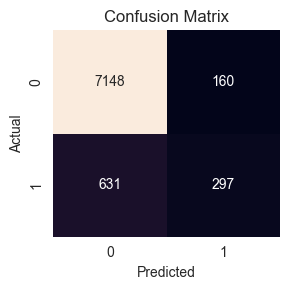

In [ ]:
bank_campaign_cm = confusion_matrix(y_test, y_pred)
# Dibujaremos esta matriz para hacerla más visual
df_cm = pd.DataFrame(bank_campaign_cm)
plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Optimización de resultados

In [156]:
hyperparams = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
               'penalty': ['l1', 'l2', 'elasticnet', None],
               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Inicializamos la cuadrícula
grid = GridSearchCV(model,
                    hyperparams,
                    scoring="accuracy",
                    cv=5)
grid

,estimator,LogisticRegre...ndom_state=24)
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [ ]:
grid.fit(X_train, y_train)
grid.best_params_

{'C': 1, 'penalty': 'l2', 'solver': 'newton-cg'}

In [ ]:
best_model_grid = LogisticRegression(penalty='l2',
                                      C=1,
                                      solver='newton-cg')
best_model_grid.fit(X_train, y_train)
y_pred_grid = best_model_grid.predict(X_test)
grid_accuracy = accuracy_score(y_test, y_pred_grid)
model_accuracy, grid_accuracy

(0.9039582321515298, 0.9039582321515298)

#### Utilizando best_estimator directamente

In [159]:
grid.best_estimator_

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,24
,solver,'newton-cg'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
best_model_estimator = grid.best_estimator_
y_pred_estimator = best_model_estimator.predict(X_test)
best_estimator_accuracy = accuracy_score(y_test, y_pred_estimator)
model_accuracy, best_estimator_accuracy

(0.9039582321515298, 0.9039582321515298)

#### El ajuste de hiperparámetros con gridsearch no mejora el resultado 

#### Random search

In [161]:
# Definimos los parámetros que queremos ajustar
hyperparams = {'C': np.logspace(-4, 4, 20),
               'penalty': ['l1', 'l2', 'elasticnet', None],
               'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}

# Inicializamos la búsqueda aleatoria
random_search = RandomizedSearchCV(model,
                                   hyperparams,
                                   n_iter=100,
                                   scoring="accuracy",
                                   cv=5,
                                   random_state=24)
random_search

,estimator,LogisticRegre...ndom_state=24)
,param_distributions,"{'C': array([1.0000...00000000e+04]), 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,n_iter,100
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,24
,error_score,nan


In [ ]:
random_search.fit(X_train, y_train)
f"Mejores hiperparámetros: {random_search.best_params_}"

"Mejores hiperparámetros: {'solver': 'liblinear', 'penalty': 'l1', 'C': np.float64(0.23357214690901212)}"

In [164]:
model_random_search = LogisticRegression(penalty="l1",
                                         C=0.2335,
                                         solver="liblinear")

model_random_search.fit(X_train, y_train)
y_pred_random = model_random_search.predict(X_test)
random_search_accuracy = accuracy_score(y_test, y_pred_random)
random_search_accuracy

0.9040796503156873

#### El ajuste de hiperparámetros con randomsearch no tiene una mejora sustancial así que no lo tenemos en cuenta